# Pair Correlation Functions (netPCF)

The pair correlation function (PCF) is a widely used tool in spatial statistics for quantifying spatial relationships across multiple length scales. Rather than summarising a point pattern with a single statistic, the PCF measures how the local density of points changes as a function of distance. At each distance, it compares the observed density of points contain within a kernel centred about each point at that distance, with the density expected under a statistical null model of spatial positions, providing a scale-dependent measure of spatial organisation.

Recently, the PCF was extended to spatial networks in:

**Moore et al. (2026). *netPCF: Geometry-aware Pair Correlation Functions for Spatial Biology*.** DOI: ...

The netPCF reformulates the PCF on spatial networks by defining the continuum of space along the network edges and measuring distances using network (geodesic) distance rather than Euclidean distance, using the data itself to define the domain of interest. The statistical null here is Complete Spatial Randomness on the network (a common choice when no prior knowledge of spatial distribution is known), so the interpretation of netPCF is:

* Values greater than **1** indicate clustering (co-localisation) at that distance.
* Values less than **1** indicate spatial exclusion or inhibition.
* Values close to **1** indicate spatial randomness.

This notebook introduces the simplest form of the network pair correlation function, `netPCF`, which quantifies the spatial correlations within a single population of nodes. We'll begin by importing a sample dataset, and creating a spatial network with labels.

(<Figure size 960x720 with 2 Axes>, <Axes: >)

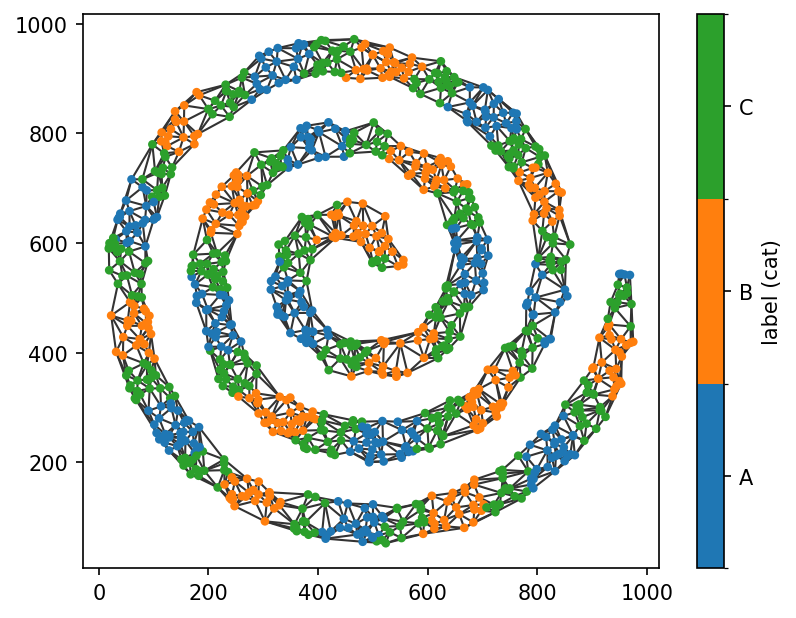

In [1]:
import spacenet as sn
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 150

# load in the example dataset 'sprial'
spiral_data = sn.datasets.load_dataset('spiral')

# extract the point data and labels
points = np.array([spiral_data['x'],spiral_data['y']]).T
cat_labels = spiral_data['Marker (categorical)']

# generate a spatial network and add the labels
spatial_net = sn.utils.spatial_network_from_points(points,max_edge_distance=77)
sn.utils.add_node_labels(spatial_net,labels=cat_labels,node_label_name='label (cat)')

# plot the spatial network with nodes colored by the demo labels 
sn.utils.plot_spatial_network(spatial_net,node_label_name='label (cat)')

Although we're computing the single-population network PCF (`netPCF`), we'll use the `cross_pair_correlation_function()` function. This is because `netPCF` is simply a special case of the more general cross-network PCF, which quantifies spatial relationships between two distinct node populations. We'll introduce the full cross-network formulation in the next tutorial.

As a simple validation, the points defining the spiral were generated from a Poisson point process. Since a Poisson point process corresponds to complete spatial randomness (CSR), irrespective of the geometry of the underlying domain, we expect the estimated pair correlation function to remain close to **1** across all distances.

To compute the network PCF, there are three key parameters:

* `spatial_kernel_bandwidth`: the one-sided bandwidth of the spatial kernel used to estimate local point densities.
* `r_max`: the maximum network distance over which to compute the pair correlation function.
* `r_step`: the spacing between successive distance values.

Additional parameters control the choice and shape of the spatial kernel, but we'll use the default settings in this tutorial.

Let's now compute the network PCF for all nodes in the spiral network. By default, `cross_pair_correlation_function()` uses every node in the spatial network unless specific node populations are provided.


In [2]:
# estimate the netPCF over all nodes in the spatial network
radii,pcf_values = sn.point_patterns.cross_pair_correlation_function(spatial_net,
                                                                     spatial_kernel_bandwidth=50,
                                                                     r_max=500,
                                                                     r_step=10)

Computing node-node distances...


Computing contributions: 100%|██████████| 1159/1159 [00:03<00:00, 299.89contributions/s]


By default, `cross_pair_correlation_function()` returns two outputs:

1. `radii`: the network distances at which the pair correlation function is evaluated.
2. `pcf_values`: the corresponding estimated pair correlation values.

Let's visualise the result by plotting the estimated pair correlation function alongside the CSR expectation of **1**.


Text(0, 0.5, 'Pair Correlation')

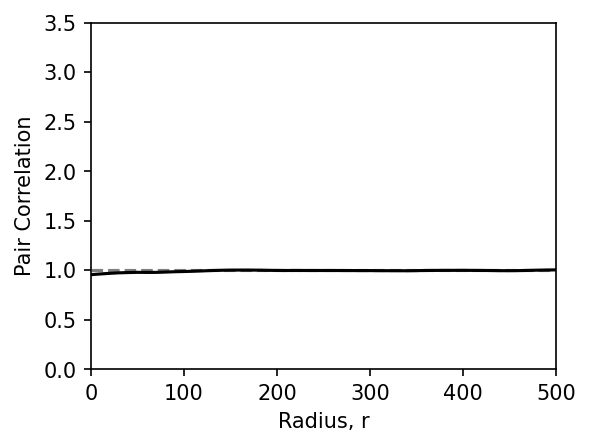

In [3]:
# plot the outputs 
fig,ax=plt.subplots(figsize=(4,3))
ax.axhline(1,linestyle='--',color='tab:grey')
ax.plot(radii,pcf_values,color='black')
ax.set_ylim(0,3.5)
ax.set_xlim(0,500)
ax.set_xlabel('Radius, r')
ax.set_ylabel('Pair Correlation')

The estimated pair correlation function remains close to **1** across the full range of network distances, indicating that the point pattern is consistent with complete spatial randomness (CSR) over the spatial network. This is the expected result, as the dataset was generated from a Poisson point process. The slight reduction below **1** at very short distances is a boundary effect caused by the thin spiral geometry, where much of the network lies close to the domain boundary.

To assess the uncertainty of the estimated pair correlation function, SpaceNet implements a spatial bootstrap procedure for constructing confidence intervals. This approach, originally developed for Euclidean domains and extended to spatial networks in the reference paper, estimates the spatial variability of the correlation function across the network.

Confidence intervals can be computed by setting `return_confidence_interval=True`, which returns the lower and upper 95% confidence bounds alongside the pair correlation estimate.

Let's repeat the analysis, this time requesting the confidence intervals.


In [4]:
# estimate netPCF over all nodes with the confidence interval
radii,pcf_values,con_inter = sn.point_patterns.cross_pair_correlation_function(spatial_net,
                                                                               spatial_kernel_bandwidth=50,
                                                                               r_max=500,
                                                                               r_step=10,
                                                                               return_confidence_interval=True)

Getting cached node-node distances...


Computing contributions: 100%|██████████| 1159/1159 [00:02<00:00, 506.38contributions/s]


Computing confidence intervals via spatial bootstrap...


The function now returns an additional output, `con_inter`, containing the lower and upper 95% confidence bounds for the estimated pair correlation function. We can visualise these confidence intervals as a shaded region around the estimate, as shown below.

Text(0, 0.5, 'Pair Correlation')

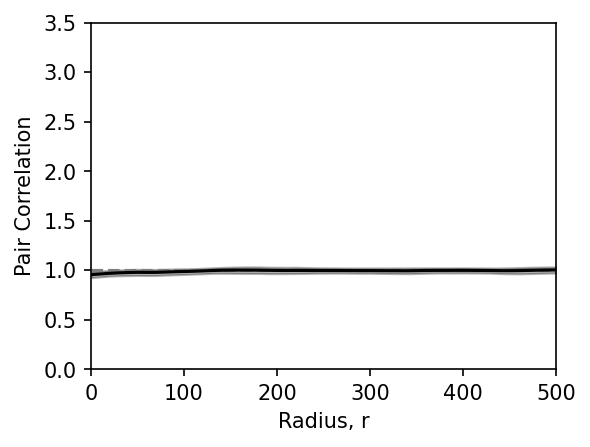

In [5]:
# plot the output 
fig,ax=plt.subplots(figsize=(4,3))
ax.axhline(1,linestyle='--',color='tab:grey')
ax.fill_between(radii,con_inter[0],con_inter[1],alpha=0.3,color='black')
ax.plot(radii,pcf_values,color='black')
ax.set_ylim(0,3.5)
ax.set_xlim(0,500)
ax.set_xlabel('Radius, r')
ax.set_ylabel('Pair Correlation')

The confidence intervals are relatively narrow, indicating that the estimated pair correlation function is spatially consistent across the network. In other words, the local correlation estimates obtained from different regions of the network show relatively little variation.

So far, we've computed the network PCF using every node in the spatial network. In many applications, however, we're interested in the spatial organisation of a specific node population. For example, we may wish to quantify the spatial distribution of only the nodes labelled `A`.

This can be achieved by passing a subset of node IDs to `cross_pair_correlation_function()`. When the same subset is supplied as both the reference and target populations, the function computes the standard network pair correlation function (`netPCF`) for that node population.

**Note:** The analysis domain is defined by the edges of the spatial network, not by the subset of nodes selected for analysis. Consequently, the estimated pair correlation function is always interpreted relative to the complete spatial network supplied to `cross_pair_correlation_function()`, even when only a subset of nodes is used to compute the statistic.

Let's first use the query functionality to identify the nodes labelled `A`, and then compute the network PCF for this subset.




In [6]:
# get the node IDs of all nodes with label A
nodes_A = sn.utils.query_nodes(spatial_net,node_label_name='label (cat)',relation='==',node_label_value='A')

# estimate netPCF over all points with label A 
radii_a,pcf_values_a,con_inter_a = sn.point_patterns.cross_pair_correlation_function(spatial_net,
                                                                                     nodes_a=nodes_A,
                                                                                     nodes_b=nodes_A,
                                                                                     spatial_kernel_bandwidth=50,
                                                                                     r_max=500,
                                                                                     r_step=10,
                                                                                     return_confidence_interval=True)

Getting cached node-node distances...


Computing contributions: 100%|██████████| 326/326 [00:00<00:00, 553.19contributions/s]

Computing confidence intervals via spatial bootstrap...


As before, we can plot the estimated pair correlation function together with its corresponding confidence intervals. For comparison, we'll also include the estimate computed using all nodes in the spatial network.


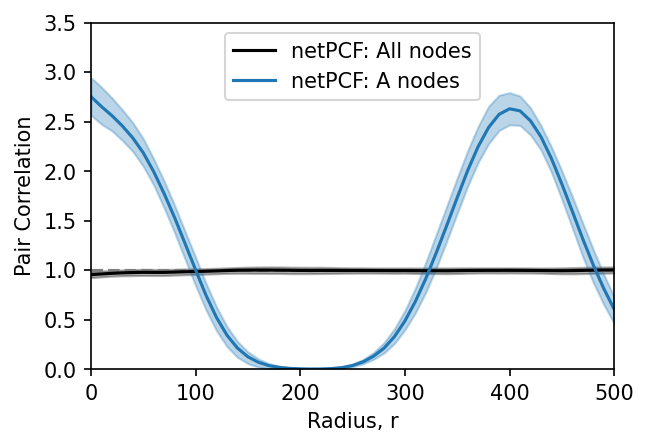

In [7]:
# plot the PCF curves estimated over the points A and over all nodes for comparison
fig,ax=plt.subplots(figsize=(4.5,3))
ax.axhline(1,linestyle='--',color='tab:grey')

ax.fill_between(radii,con_inter[0],con_inter[1],alpha=0.3,color='black')
ax.plot(radii,pcf_values,color='black',label='netPCF: All nodes')

ax.fill_between(radii_a,con_inter_a[0],con_inter_a[1],alpha=0.3,color='tab:blue')
ax.plot(radii_a,pcf_values_a,color='tab:blue',label='netPCF: A nodes')

ax.set_ylim(0,3.5)
ax.set_xlim(0,500)
ax.set_xlabel('Radius, r')
ax.set_ylabel('Pair Correlation')
ax.legend()

Unlike the estimate computed using all nodes, the network PCF for the `A`-labelled nodes exhibits alternating peaks and troughs. Peaks (values greater than **1**) indicate clustering at particular network distances, while troughs (values less than **1**) indicate spatial exclusion.

This behaviour arises because the `A`-labelled nodes are arranged periodically along the spiral. As the pair correlation function is evaluated over increasing network distances, it encounters alternating distances at which `A`-labelled nodes are either more or less likely to occur than expected under complete spatial randomness. The resulting oscillatory pattern reflects the regular spacing of this node population along the network.

There are many additional parameters that can be explored. In particular, the kernel bandwidth and kernel shape determine the spatial scale over which local point densities are estimated and therefore influence the appearance of the pair correlation function. There is no universally optimal choice of these parameters, so exploring different settings can provide additional insight into the spatial organisation of your data.

In summary, the network pair correlation function (`netPCF`) provides a principled way to quantify spatial organisation over a spatial network, identifying both the characteristic length scales and the nature of spatial interactions, including clustering and spatial exclusion.
